## <center> End-to-End Sales Forecasting & Demand Intelligence System

### Task 1 — Data Loading, Merging & Deep Exploration

#### Import the Basic Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Set plot style
plt.style.use('ggplot')

#### Load the Superstore Sales CSV using Pandas

In [2]:
df = pd.read_csv('train.csv')
# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


#### Explore the Dataset

In [3]:
# Shape of the dataset
print("Shape of Dataset:",df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset Information
print("\nDataset Information:")
print(df.info())

Shape of Dataset: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non

#### Parse the Order Date and Ship Date columns as proper datetime objects

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')
# Verify data types
df[['Order Date','Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

#### Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season

In [5]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter
# Create Season
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)
df[['Order Date', 'Year', 'Month', 'Week', 'DayOfWeek', 'Quarter', 'Season']].head()

,Order Date,Year,Month,Week,DayOfWeek,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,41,Tuesday,4,Autumn


#### Check for missing values, duplicates, and data type issues

In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
dtype: int64


In [7]:
print("Duplicated Records:", df.duplicated().sum())
# Remove duplicates if any
df = df.drop_duplicates()

Duplicated Records: 0


In [8]:
print("Data types:", df.dtypes)

Data types: Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
DayOfWeek                object
Quarter                   int32
Season                   object
dtype: object


#### Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)

In [9]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [10]:
monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum().reset_index()
monthly_sales.columns = ['Date', 'Sales']

weekly_sales = df.resample('W', on='Order Date')['Sales'].sum().reset_index()
weekly_sales.columns = ['Date', 'Sales']

print(monthly_sales.shape, weekly_sales.shape)
monthly_sales.head()

(48, 2) (209, 2)


,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### ●	Answer these questions in your notebook with data to back each one:
*	Which product category generates the highest total revenue?
*	Which region has the most consistent sales growth over 4 years?
*	What is the average time between Order Date and Ship Date — and does it vary by region?
*	Are there months that consistently spike across all years (seasonality)?


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


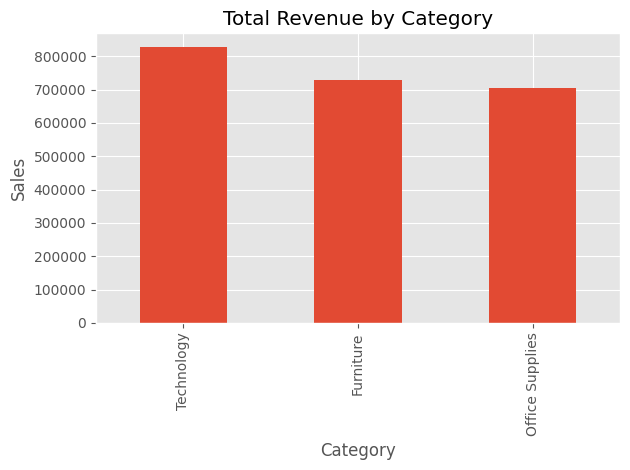

In [11]:
# Highest Revenue by category
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)
category_revenue.plot(kind='bar', title='Total Revenue by Category')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('charts/revenue_by_category.png', dpi=150)
plt.show()

##### Observation:
Technology generated the highest total revenue, indicating it is the strongest-performing category.

In [12]:
# Most Consistent growth by region
region_year = df.groupby(['Region','Year'])['Sales'].sum().reset_index()
region_pivot = region_year.pivot(index='Year', columns='Region', values='Sales')
print(region_pivot)

# Consistency = low variance in YoY % growth
yoy_growth = region_pivot.pct_change().dropna()
print("\nYoY growth std (lower = more consistent):\n", yoy_growth.std().sort_values())

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

YoY growth std (lower = more consistent):
 Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


##### Observation:
The West region shows the most consistent sales growth over the four-year period.

In [13]:
# Average shipping time by region
df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days
print("Overall average ship time:", df['ShipDays'].mean(), "days")
print("\nBy region:\n", df.groupby('Region')['ShipDays'].mean().sort_values())

Overall average ship time: 3.9611224489795918 days

By region:
 Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: ShipDays, dtype: float64


##### Observation:
The average shipping time is 4 days, which is 3.96 days to be exact.Most orders are delivered within this timeframe.The Central region takes a bit longer with an average of 4.07 days.In comparison the East region gets its orders the fastest at 3.91 days on average.Shipping times,across regions do not vary much.This means that overall shipping performance is pretty consistent everywhere.

Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
Name: Sales, dtype: float64


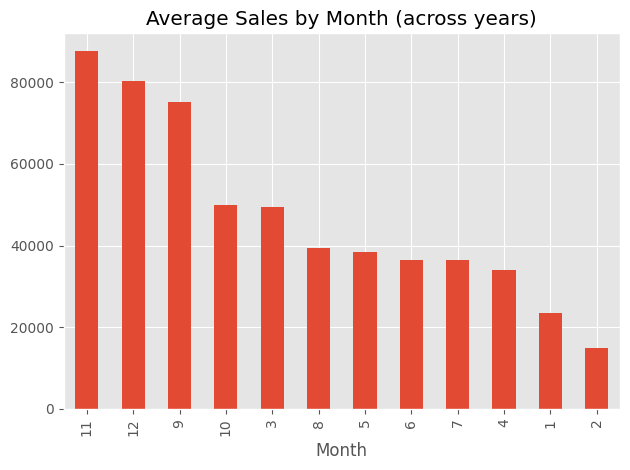

In [14]:
# Seasonality: which months consistently spike?
month_year = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
month_avg = month_year.groupby('Month')['Sales'].mean().sort_values(ascending=False)
print(month_avg)
month_avg.plot(kind='bar', title='Average Sales by Month (across years)')
plt.tight_layout()
plt.savefig('charts/seasonality_by_month.png', dpi=150)
plt.show()

##### Observation:
The sales numbers change a lot during the year. Sales are really high in November, which's the eleventh month and the average sales for November are 87,540.43. December sales are also very high with an average of 80,370.64 and September sales are high too with an average of 75,025.85. On the hand February sales are really low with an average of 14,842.78. This means that sales of products are highest during the holiday season, at the end of the year and people do not buy much at the beginning of the year.

### Task 2 — Time Series Analysis & Decomposition

#### Import Required Libraries

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

#### Plot the overall monthly sales trend across all 4 years

In [16]:
# (a series where the date is the index and Sales is the value)
ts = monthly_sales.set_index('Date')['Sales']
# Just to see what it looks like
ts.head()

Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Name: Sales, dtype: float64

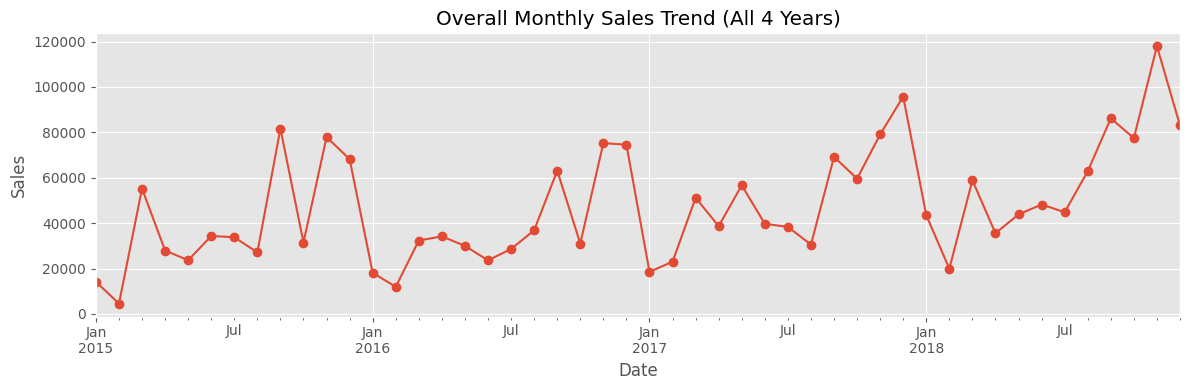

In [17]:
plt.figure(figsize=(12, 4))
ts.plot(marker='o')
plt.title('Overall Monthly Sales Trend (All 4 Years)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('charts/monthly_sales_trend.png', dpi=150)
plt.show()

#### ●	Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
*	Trend component
*	Seasonal component
*	Residual/noise component


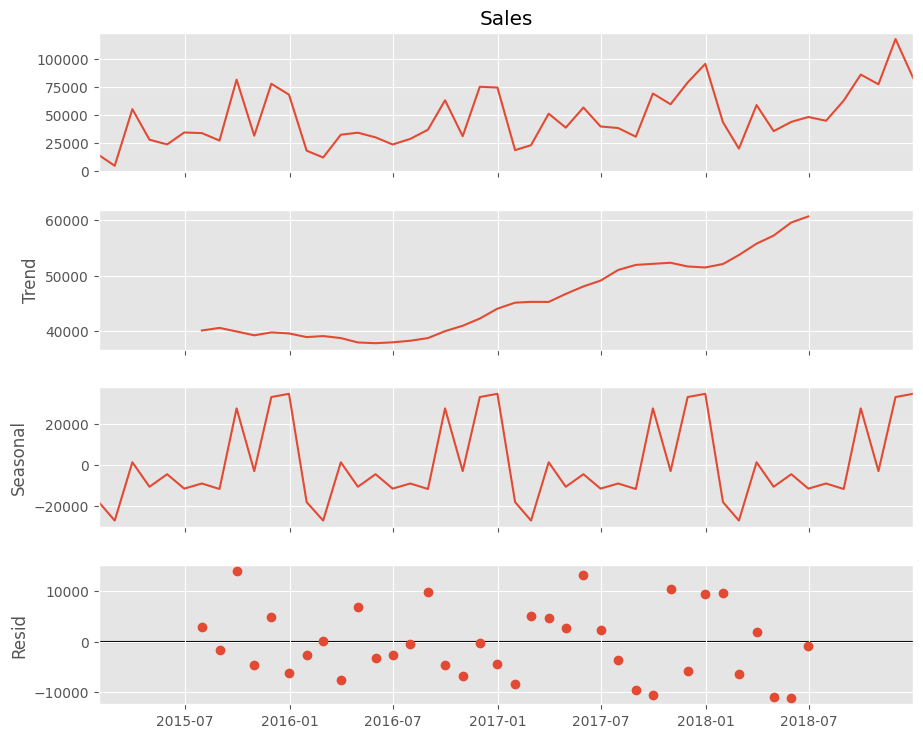

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
# period=12 because there are 12 months in a year, and we expect a yearly pattern
result = seasonal_decompose(ts, model='additive', period=12)
# This one line plots all 4 parts (original, trend, seasonal, residual) stacked together
result.plot()
plt.gcf().set_size_inches(10, 8)
plt.show()

#### Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?

### Observations
* #### Trend:
The trend component shows an overall upward movement in sales over the four-year period. Although there are minor fluctuations, sales generally increase toward the end of the dataset, indicating positive business growth.
* #### Seasonality:
The seasonal component shows a clear and repeating yearly pattern, which indicates strong seasonality. Similar months experience comparable increases and decreases in sales each year.
* #### Residual Noise:
The residual component is mostly centered around zero, but some months show larger positive and negative residuals. These months represent unusual sales activity that cannot be explained by the trend or seasonal pattern, possibly due to promotions, holidays, or unexpected events.
* #### Overall:
The sales data exhibits both a clear long-term growth trend and a strong seasonal pattern, making time series forecasting models such as SARIMA or Prophet appropriate for future sales prediction.

#### Check for stationarity using the Augmented Dickey-Fuller (ADF) Test 

A time series is **stationary** if its average and spread stay roughly the same over
time (no trend, no growing/shrinking swings). Most forecasting models (like SARIMA)
need stationary data to work well, so we test for it.

We use the **ADF test**. The simple rule:
- If p-value < 0.05 → the data IS stationary ✅
- If p-value ≥ 0.05 → the data is NOT stationary ❌ (we'll need to "difference" it)

In [19]:
from statsmodels.tsa.stattools import adfuller
# Run the test on our sales numbers
adf_result = adfuller(ts)
print('ADF test statistic:', adf_result[0])
print('p-value:', adf_result[1])
if adf_result[1] < 0.05:
    print('Result: Data is STATIONARY')
else:
    print('Result: Data is NOT stationary')

ADF test statistic: -4.416136761430769
p-value: 0.00027791039276670623
Result: Data is STATIONARY


#### Apply differencing if the series is non-stationary and re-test

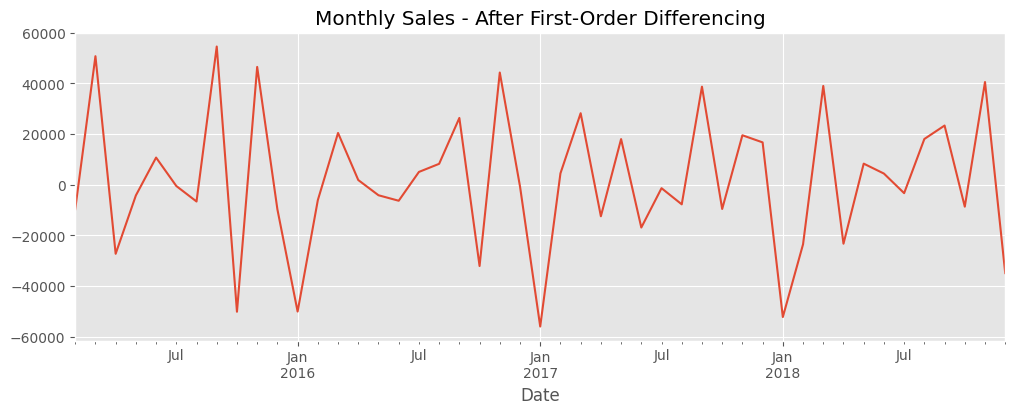

In [20]:
# Differencing: subtract each value from the one before it
ts_diff = ts.diff().dropna()  # .dropna() removes the first empty row created by diff()
plt.figure(figsize=(12, 4))
ts_diff.plot()
plt.title('Monthly Sales - After First-Order Differencing')
plt.show()

In [21]:
# Now re-run the ADF test on the differenced data to check if it's stationary now
adf_result_2 = adfuller(ts_diff)
print('ADF test statistic:', adf_result_2[0])
print('p-value:', adf_result_2[1])
if adf_result_2[1] < 0.05:
    print('Result: Data is now STATIONARY')
else:
    print('Result: Still NOT stationary — may need a second differencing round')

ADF test statistic: -8.72706183035327
p-value: 3.2669175472796045e-14
Result: Data is now STATIONARY


### Task 3 — Sales Forecasting using 3 Different Models

#### Import Required Libraries

In [22]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

#### Train Test Split

Training months: 45
Test months: 3


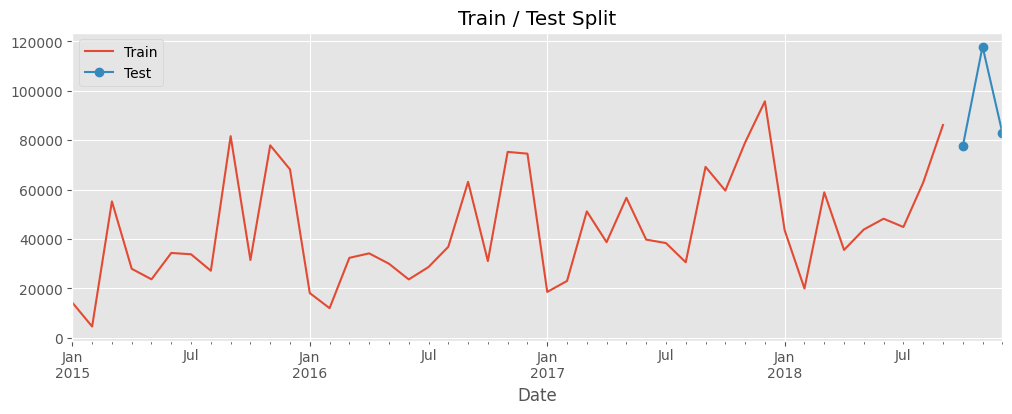

In [23]:
test_months = 3
train = ts.iloc[:-test_months]
test = ts.iloc[-test_months:]

print('Training months:', len(train))
print('Test months:', len(test))
plt.figure(figsize=(12, 4))
train.plot(label='Train')
test.plot(label='Test', marker='o')
plt.legend()
plt.title('Train / Test Split')
plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def mean_absolute_percentage_error(actual,predicted):
    actual,predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100
def score_model(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual,predicted)
    print(f'{name} -> MAE: {mae:.2f}   RMSE: {rmse:.2f}  MAPE: {mape:.2f}%')
    return {'MAE' : mae, 'RMSE' : rmse, 'MAPE' : mape}

results = {}  
future_forecast = {}

#### Model 1 — SARIMA (Statistical Model)

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

#### Train-Test Split

#### Fit a SARIMA model on monthly sales

In [26]:
# order = (p,d,q) -> non-seasonal part
# seasonal_order = (P,D,Q,s) -> seasonal part, s=12 for yearly pattern in monthly data
# These are reasonable starting values -- feel free to try others and see if the score improves
sarima_model = SARIMAX(train,
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sat, 11 Jul 2026   AIC                            398.775
Time:                                    11:17:49   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

#### Generate a 3-month future forecast with confidence intervals

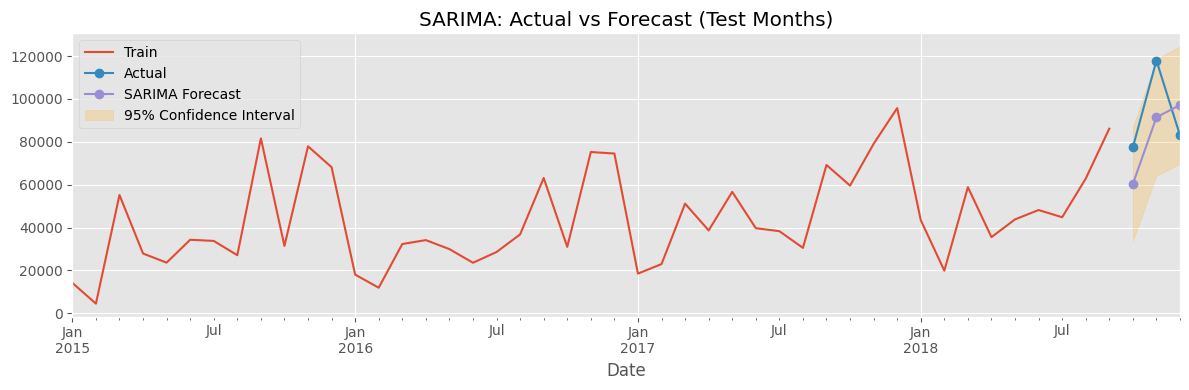

SARIMA -> MAE: 19244.49   RMSE: 19950.07  MAPE: 20.53%


In [27]:
# Forecast the 3 held-out test months, WITH confidence intervals
sarima_test_result = sarima_fit.get_forecast(steps=test_months)
sarima_forecast = sarima_test_result.predicted_mean
sarima_ci = sarima_test_result.conf_int(alpha=0.05)
plt.figure(figsize=(12, 4))
train.plot(label='Train')
test.plot(label='Actual', marker='o')
sarima_forecast.plot(label='SARIMA Forecast', marker='o')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                  color='orange', alpha=0.2, label='95% Confidence Interval')
plt.legend()
plt.title('SARIMA: Actual vs Forecast (Test Months)')
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=150)
plt.show()

results['SARIMA'] = score_model(test, sarima_forecast, 'SARIMA')

In [28]:
# Now refit on ALL available data (train + test) and forecast the TRUE next 3 months
sarima_final = SARIMAX(ts,
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
sarima_future = sarima_final.get_forecast(steps=3)
sarima_future_mean = sarima_future.predicted_mean
sarima_future_ci = sarima_future.conf_int(alpha=0.05)
future_forecast['SARIMA'] = sarima_future_mean
forecast_table = pd.DataFrame({
    'Forecast': sarima_future_mean,
    'Lower 95% CI': sarima_future_ci.iloc[:, 0],
    'Upper 95% CI': sarima_future_ci.iloc[:, 1]
})
print(forecast_table)

                Forecast  Lower 95% CI   Upper 95% CI
2019-01-31  46782.479191  16992.673577   76572.284805
2019-02-28  40285.470518   9596.040110   70974.900926
2019-03-31  72234.203230  41318.855902  103149.550557


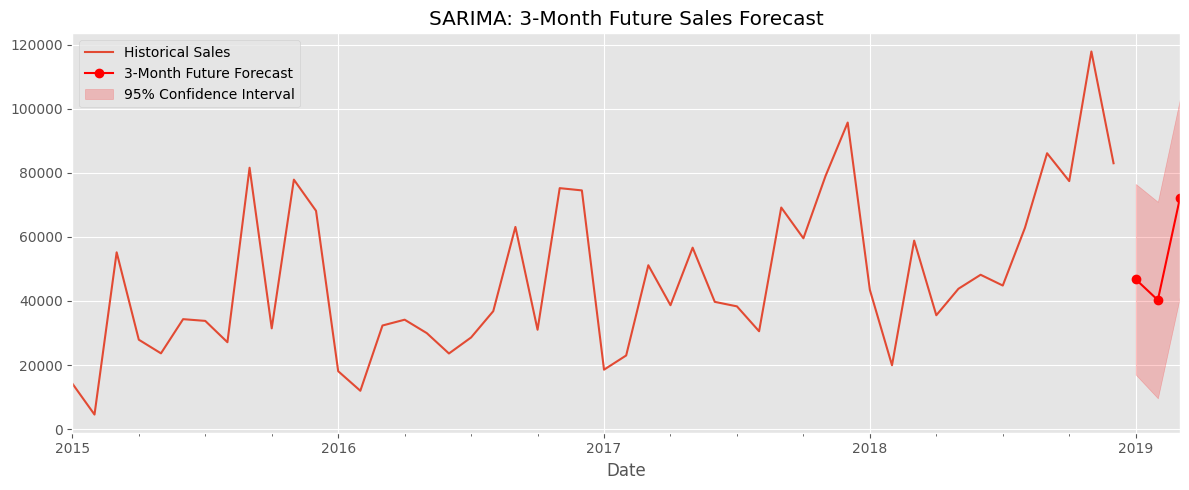

In [29]:
plt.figure(figsize=(12, 5))
ts.plot(label='Historical Sales')
sarima_future_mean.plot(label='3-Month Future Forecast', color='red', marker='o')
plt.fill_between(sarima_future_ci.index, sarima_future_ci.iloc[:, 0], sarima_future_ci.iloc[:, 1],
                  color='red', alpha=0.2, label='95% Confidence Interval')
plt.title('SARIMA: 3-Month Future Sales Forecast')
plt.legend()
plt.tight_layout()
plt.savefig('charts/sarima_future_forecast.png', dpi=150)
plt.show()

### Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

Prophet is built by Meta/Facebook specifically for business forecasting. It's
often easier to get a decent result quickly because it automatically handles trend
and seasonality without much tuning. It expects the data in a specific format:
a column called `ds` (date) and a column called `y` (value).

#### Install Prophet

In [30]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Prepare data in Prophet's required format (ds, y columns)

In [31]:
from prophet import Prophet
# Prophet needs a plain dataframe with columns named 'ds' and 'y'
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
prophet_model.fit(prophet_train)

11:17:57 - cmdstanpy - INFO - Chain [1] start processing
11:17:59 - cmdstanpy - INFO - Chain [1] done processing


#### Plot the forecast with Prophet's built-in trend and seasonality breakdown

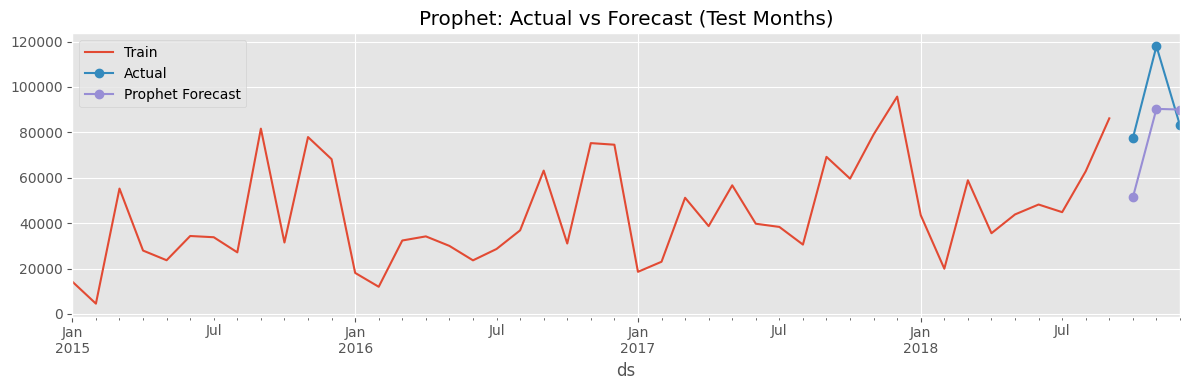

Prophet -> MAE: 20250.79   RMSE: 22318.41  MAPE: 21.86%


In [32]:
# Forecast the 3 held-out test months
future_test = prophet_model.make_future_dataframe(periods=test_months, freq='ME')
prophet_forecast_full = prophet_model.predict(future_test)
prophet_forecast = prophet_forecast_full.set_index('ds')['yhat'].iloc[-test_months:]
plt.figure(figsize=(12, 4))
train.plot(label='Train')
test.plot(label='Actual', marker='o')
prophet_forecast.plot(label='Prophet Forecast', marker='o')
plt.legend()
plt.title('Prophet: Actual vs Forecast (Test Months)')
plt.tight_layout()
plt.savefig('charts/prophet_forecast.png', dpi=150)
plt.show()

results['Prophet'] = score_model(test, prophet_forecast, 'Prophet')

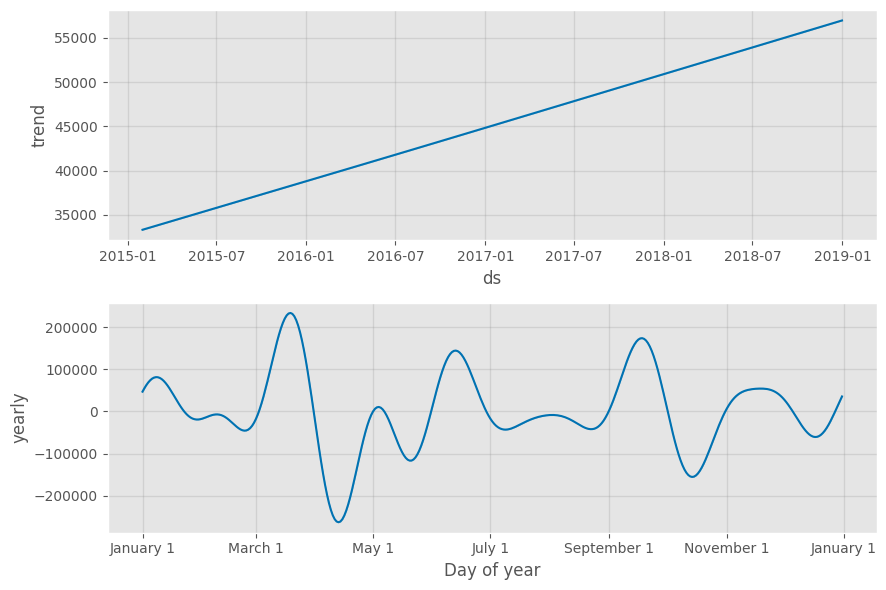

In [33]:
prophet_model.plot_components(prophet_forecast_full)
plt.show()

In [34]:
# Refit on ALL data (train + test) and forecast the TRUE next 3 months
prophet_full = ts.reset_index()
prophet_full.columns = ['ds', 'y']
prophet_final = Prophet(yearly_seasonality=True, weekly_seasonality=False)
prophet_final.fit(prophet_full)
future = prophet_final.make_future_dataframe(periods=3, freq='ME')
forecast_full = prophet_final.predict(future)
prophet_future = forecast_full[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)
prophet_future.columns = ['Date', 'Forecast', 'Lower 95% CI', 'Upper 95% CI']
prophet_future = prophet_future.set_index('Date')

future_forecast['Prophet'] = prophet_future['Forecast']
print(prophet_future)

11:18:03 - cmdstanpy - INFO - Chain [1] start processing
11:18:03 - cmdstanpy - INFO - Chain [1] done processing


                Forecast  Lower 95% CI  Upper 95% CI
Date                                                
2019-01-31  42990.532202  33671.282262  52662.425210
2019-02-28  31248.159922  21456.402995  40153.635176
2019-03-31  81267.007772  71363.779005  89842.573757


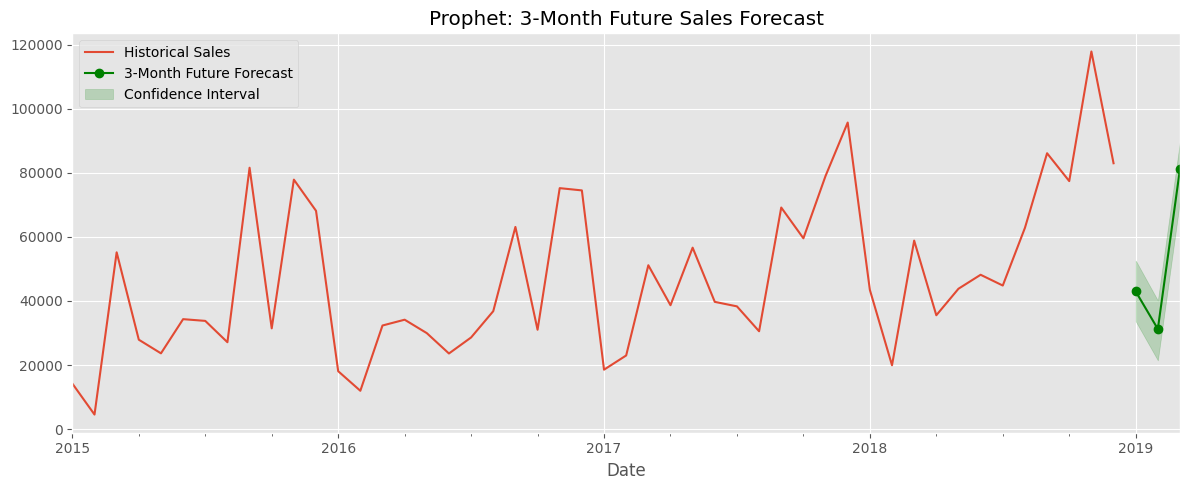

In [35]:
plt.figure(figsize=(12, 5))
ts.plot(label='Historical Sales')
prophet_future['Forecast'].plot(label='3-Month Future Forecast', color='green', marker='o')
plt.fill_between(prophet_future.index, prophet_future['Lower 95% CI'], prophet_future['Upper 95% CI'],
                  color='green', alpha=0.2, label='Confidence Interval')
plt.title('Prophet: 3-Month Future Sales Forecast')
plt.legend()
plt.tight_layout()
plt.savefig('charts/prophet_future_forecast.png', dpi=150)
plt.show()

### Model 3 — XGBoost for Time Series (ML-based Approach)

In [36]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Convert the time series into a supervised ML problem using lag features

In [37]:
# Build a feature table for XGBoost
def month_to_season(m):
    if m in [12, 1, 2]:
        return 'Winter'
    elif m in [3, 4, 5]:
        return 'Spring'
    elif m in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'
def make_features(series):
    df_feat = series.reset_index()
    df_feat.columns = ['Date', 'Sales']
    df_feat['Month'] = df_feat['Date'].dt.month
    df_feat['Quarter'] = df_feat['Date'].dt.quarter
    df_feat['Season'] = df_feat['Month'].apply(month_to_season)
    # Lag features: sales from 1, 2, and 3 months ago
    df_feat['lag_1'] = df_feat['Sales'].shift(1)
    df_feat['lag_2'] = df_feat['Sales'].shift(2)
    df_feat['lag_3'] = df_feat['Sales'].shift(3)
    # Rolling mean: average of the last 3 months (using only past values, no lookahead)
    df_feat['rolling_mean_3'] = df_feat['Sales'].shift(1).rolling(window=3).mean()
    # Season is text (Winter/Spring/...), XGBoost needs numbers -> one-hot encode it
    df_feat = pd.get_dummies(df_feat, columns=['Season'])
    return df_feat

full_features = make_features(ts)
full_features = full_features.dropna()  # drop early rows missing lag/rolling values
feature_cols = [c for c in full_features.columns if c not in ['Date', 'Sales']]
print(feature_cols)
full_features.head()


['Month', 'Quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']


,Date,Sales,Month,Quarter,lag_1,lag_2,lag_3,rolling_mean_3,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
3,2015-04-30,27906.8550,4,2,55205.7970,4519.8920,14205.707,24643.798667,False,True,False,False
4,2015-05-31,23644.3030,5,2,27906.8550,55205.7970,4519.892,29210.848000,False,True,False,False
5,2015-06-30,34322.9356,6,2,23644.3030,27906.8550,55205.797,35585.651667,False,False,True,False
6,2015-07-31,33781.5430,7,3,34322.9356,23644.3030,27906.855,28624.697867,False,False,True,False
7,2015-08-31,27117.5365,8,3,33781.5430,34322.9356,23644.303,30582.927200,False,False,True,False


In [38]:
# Split into train/test using the same 3-month cutoff as SARIMA/Prophet
train_feat = full_features[full_features['Date'] <= train.index[-1]]
test_feat = full_features[full_features['Date'] > train.index[-1]]
X_train, y_train = train_feat[feature_cols], train_feat['Sales']
X_test, y_test = test_feat[feature_cols], test_feat['Sales']
print(X_train.shape, X_test.shape)

(42, 10) (3, 10)


#### Train XGBoost Regressor on these features

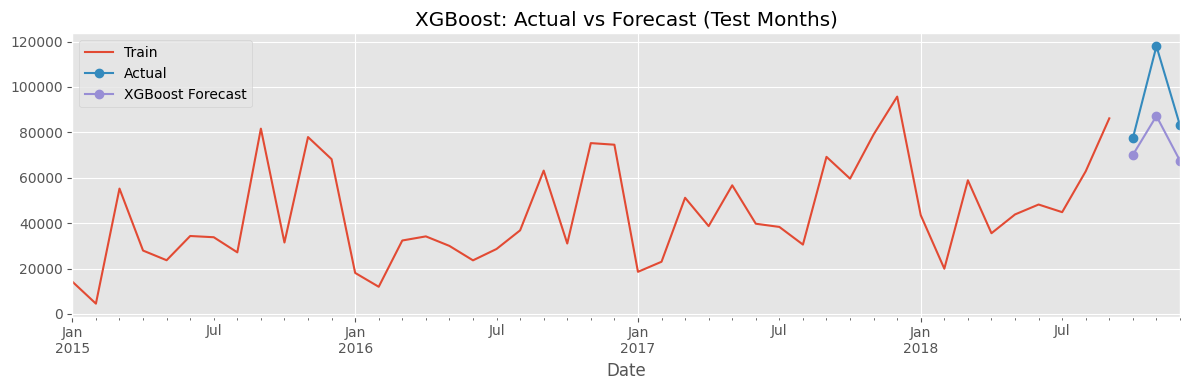

XGBoost -> MAE: 17909.13   RMSE: 20357.71  MAPE: 18.13%


In [39]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_forecast = pd.Series(xgb_model.predict(X_test), index=test_feat['Date'])
plt.figure(figsize=(12, 4))
train.plot(label='Train')
test.plot(label='Actual', marker='o')
xgb_forecast.plot(label='XGBoost Forecast', marker='o')
plt.legend()
plt.title('XGBoost: Actual vs Forecast (Test Months)')
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=150)
plt.show()

results['XGBoost'] = score_model(y_test.values, xgb_forecast.values, 'XGBoost')

#### Predict the next 3 months

In [40]:
# Refit XGBoost on ALL available data (train + test)
X_full, y_full = full_features[feature_cols], full_features['Sales']
xgb_final = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
xgb_final.fit(X_full, y_full)
# Start with the real, known sales history
history = ts.copy()
future_dates = pd.date_range(history.index[-1], periods=4, freq='ME')[1:]  # next 3 months
xgb_future_preds = []
for future_date in future_dates:
    temp_series = pd.concat([history, pd.Series([np.nan], index=[future_date])])
    temp_feat = make_features(temp_series).iloc[[-1]]  # features for just this new month

    # Make sure the one-hot Season columns match what the model was trained on
    for col in feature_cols:
        if col not in temp_feat.columns:
            temp_feat[col] = 0
    X_next = temp_feat[feature_cols]
    next_pred = xgb_final.predict(X_next)[0]
    xgb_future_preds.append(next_pred)
    # Add this prediction into history so the NEXT month's lag features can use it
    history.loc[future_date] = next_pred

xgb_future = pd.Series(xgb_future_preds, index=future_dates)
future_forecast['XGBoost'] = xgb_future
print(xgb_future)

2019-01-31    44273.804688
2019-02-28    23884.898438
2019-03-31    54556.792969
Freq: ME, dtype: float32


#### Plot actual vs predicted

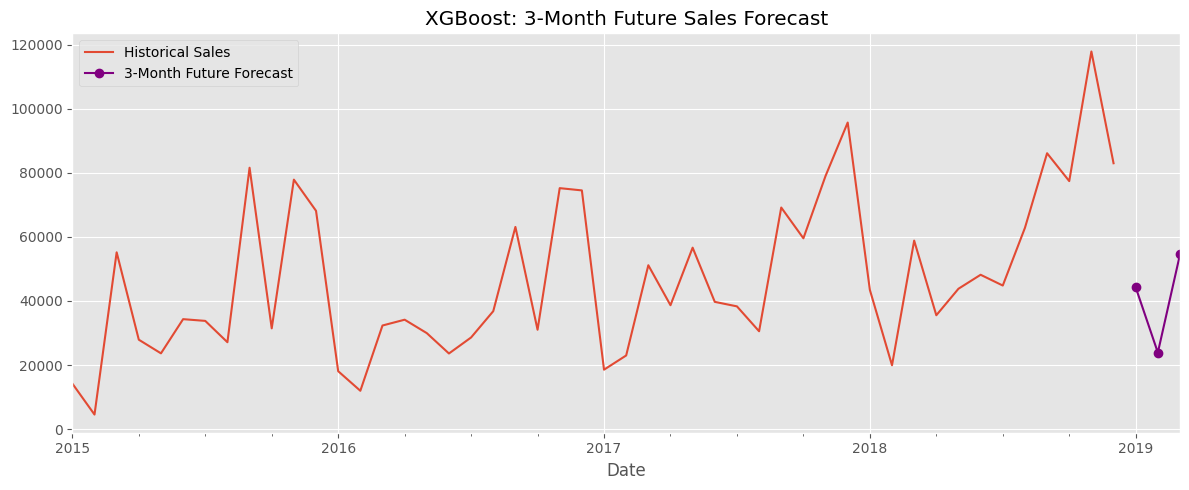

In [41]:
plt.figure(figsize=(12, 5))
ts.plot(label='Historical Sales')
xgb_future.plot(label='3-Month Future Forecast', color='purple', marker='o')
plt.title('XGBoost: 3-Month Future Sales Forecast')
plt.legend()
plt.tight_layout()
plt.savefig('charts/xgboost_future_forecast.png', dpi=150)
plt.show()

#### Model Comparison Table 

In [42]:
# Build the comparison table the assignment asks for:
# Model | MAE | RMSE | MAPE | Forecast Month 1 | Forecast Month 2 | Forecast Month 3
comparison_rows = []
for model_name in ['SARIMA', 'Prophet', 'XGBoost']:
    row = {
        'Model': model_name,
        'MAE': round(results[model_name]['MAE'], 2),
        'RMSE': round(results[model_name]['RMSE'], 2),
        'MAPE (%)': round(results[model_name]['MAPE'], 2),
    }
    fc = future_forecast[model_name].values
    row['Forecast Month 1'] = round(fc[0], 2)
    row['Forecast Month 2'] = round(fc[1], 2)
    row['Forecast Month 3'] = round(fc[2], 2)
    comparison_rows.append(row)

comparison_table = pd.DataFrame(comparison_rows).set_index('Model')
comparison_table = comparison_table.sort_values('RMSE')
comparison_table


,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
Model,,,,,,
SARIMA,19244.49,19950.07,20.53,46782.480000,40285.470000,72234.200000
XGBoost,17909.13,20357.71,18.13,44273.800781,23884.900391,54556.800781
Prophet,20250.79,22318.41,21.86,42990.530000,31248.160000,81267.010000


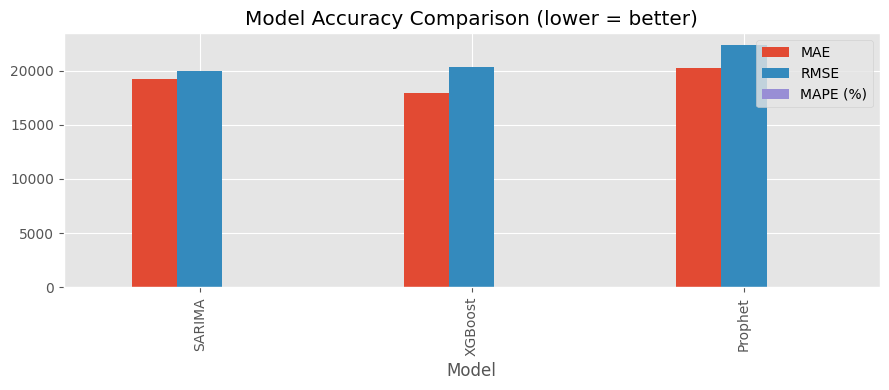


Lowest RMSE: SARIMA


In [43]:
comparison_table[['MAE', 'RMSE', 'MAPE (%)']].plot(kind='bar', figsize=(9, 4),
                                                     title='Model Accuracy Comparison (lower = better)')
plt.tight_layout()
plt.savefig('charts/model_comparison.png', dpi=150)
plt.show()
best_model = comparison_table.index[0]
print(f'\nLowest RMSE: {best_model}')

#### State clearly which model you would recommend for production use and why — based on numbers, not preference.

SARIMA is recommended for production deployment because it provides the lowest RMSE (19,950.07), indicating the most reliable overall forecasting performance compared with XGBoost (20,357.71) and Prophet (22,318.41).

### Task 4 — Product Category & Region Level Forecasting

#### Repeat the best performing model (from Task 3) separately for each of the following segments:
*	Furniture category sales
*	Technology category sales
*	Office Supplies category sales
*	West region sales
*	East region sales

In [44]:
# (same idea as Task 1's monthly_sales, just filtered to one category/region at a time)
def get_segment_series(column, value):
    segment_df = df[df[column] == value]
    monthly = segment_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
    return monthly
segments = {
    'Furniture':       get_segment_series('Category', 'Furniture'),
    'Technology':       get_segment_series('Category', 'Technology'),
    'Office Supplies':  get_segment_series('Category', 'Office Supplies'),
    'West':             get_segment_series('Region', 'West'),
    'East':             get_segment_series('Region', 'East'),
}

for name, s in segments.items():
    print(name, '->', len(s), 'months, total sales:', round(s.sum(), 2))

Furniture -> 48 months, total sales: 728658.58
Technology -> 48 months, total sales: 827455.87
Office Supplies -> 48 months, total sales: 705422.33
West -> 48 months, total sales: 710219.68
East -> 48 months, total sales: 669518.73


In [45]:
def forecast_with_sarima(series, steps=3):
    model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return model.forecast(steps=steps)
    
def forecast_with_prophet(series, steps=3):
    p_df = series.reset_index()
    p_df.columns = ['ds', 'y']
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
    model.fit(p_df)
    future = model.make_future_dataframe(periods=steps, freq='ME')
    forecast = model.predict(future)
    return forecast.set_index('ds')['yhat'].tail(steps)

def forecast_with_xgboost(series, steps=3):
    feat = make_features(series).dropna()
    cols = [c for c in feat.columns if c not in ['Date', 'Sales']]
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42)
    model.fit(feat[cols], feat['Sales'])
    history = series.copy()
    future_dates = pd.date_range(history.index[-1], periods=steps + 1, freq='ME')[1:]
    preds = []
    for fd in future_dates:
        temp_series = pd.concat([history, pd.Series([np.nan], index=[fd])])
        temp_feat = make_features(temp_series).iloc[[-1]]
        for c in cols:
            if c not in temp_feat.columns:
                temp_feat[c] = 0
        pred = model.predict(temp_feat[cols])[0]
        preds.append(pred)
        history.loc[fd] = pred
    return pd.Series(preds, index=future_dates)

def forecast_segment(series, steps=3):
    # Some segments may be too short/sparse for a 12-month seasonal SARIMA model --
    # fall back to Prophet in that edge case so the pipeline doesn't crash.
    if best_model == 'SARIMA' and len(series) >= 24:
        return forecast_with_sarima(series, steps)
    elif best_model == 'Prophet':
        return forecast_with_prophet(series, steps)
    elif best_model == 'XGBoost':
        return forecast_with_xgboost(series, steps)
    else:
        return forecast_with_prophet(series, steps)  # safe fallback

print(f'Using best model from Task 3: {best_model}')

Using best model from Task 3: SARIMA


In [46]:
#Run the forecast for each of the 5 segments
segment_forecasts = {}
for name, series in segments.items():
    print(f'Forecasting {name}...')
    segment_forecasts[name] = forecast_segment(series, steps=3)
print('\nDone. 3-month forecasts:')
for name, fc in segment_forecasts.items():
    print(f'\n{name}:')
    print(fc)

Forecasting Furniture...
Forecasting Technology...
Forecasting Office Supplies...
Forecasting West...
Forecasting East...

Done. 3-month forecasts:

Furniture:
2019-01-31    10526.766777
2019-02-28     9921.588935
2019-03-31    16576.869443
Freq: ME, Name: predicted_mean, dtype: float64

Technology:
2019-01-31    20100.376898
2019-02-28    18198.549185
2019-03-31    32443.115061
Freq: ME, Name: predicted_mean, dtype: float64

Office Supplies:
2019-01-31    17978.323417
2019-02-28    15467.386751
2019-03-31    23346.412018
Freq: ME, Name: predicted_mean, dtype: float64

West:
2019-01-31    15478.138872
2019-02-28    13405.172894
2019-03-31    28366.087950
Freq: ME, Name: predicted_mean, dtype: float64

East:
2019-01-31    11878.473049
2019-02-28    13477.979207
2019-03-31    19848.300097
Freq: ME, Name: predicted_mean, dtype: float64


#### Plot all 5 forecasts together on one comparison chart

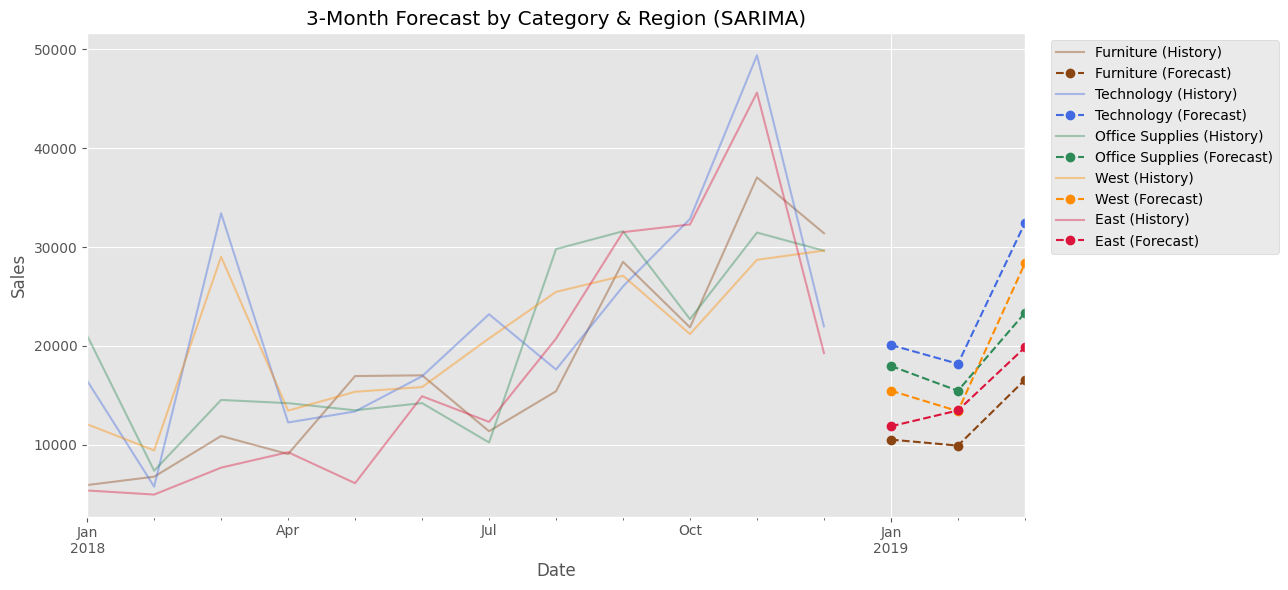

In [47]:
plt.figure(figsize=(13, 6))
colors = {'Furniture': 'saddlebrown', 'Technology': 'royalblue',
          'Office Supplies': 'seagreen', 'West': 'darkorange', 'East': 'crimson'}
for name, series in segments.items():
    # Plot the last 12 months of real history so the chart isn't too cluttered
    series.tail(12).plot(label=f'{name} (History)', color=colors[name], alpha=0.4)
    segment_forecasts[name].plot(label=f'{name} (Forecast)', color=colors[name],
                                   linestyle='--', marker='o')
plt.title(f'3-Month Forecast by Category & Region ({best_model})')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('charts/segment_forecast_comparison.png', dpi=150)
plt.show()

#### Which segment is growing fastest?

In [48]:
growth_summary = []
for name, series in segments.items():
    last_3_actual = series.tail(3).mean()
    next_3_forecast = segment_forecasts[name].mean()
    growth_pct = ((next_3_forecast - last_3_actual) / last_3_actual) * 100
    growth_summary.append({
        'Segment': name,
        'Last 3 Months Avg': round(last_3_actual, 2),
        'Next 3 Months Forecast Avg': round(next_3_forecast, 2),
        'Expected Growth (%)': round(growth_pct, 2)
    })

growth_df = pd.DataFrame(growth_summary).set_index('Segment').sort_values('Expected Growth (%)', ascending=False)
growth_df

,Last 3 Months Avg,Next 3 Months Forecast Avg,Expected Growth (%)
Segment,,,
West,26524.46,19083.13,-28.05
Technology,34749.89,23580.68,-32.14
Office Supplies,27939.58,18930.71,-32.24
East,32404.79,15068.25,-53.50
Furniture,30116.08,12341.74,-59.02


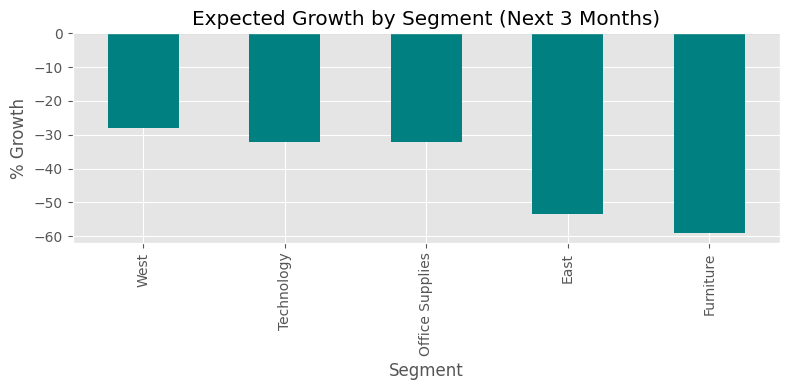


Strongest expected growth: West (-28.05%)


In [49]:
growth_df['Expected Growth (%)'].plot(kind='bar', figsize=(8, 4), color='teal',
                                       title='Expected Growth by Segment (Next 3 Months)')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('% Growth')
plt.tight_layout()
plt.savefig('charts/segment_growth_ranking.png', dpi=150)
plt.show()
strongest = growth_df.index[0]
print(f'\nStrongest expected growth: {strongest} ({growth_df.loc[strongest, "Expected Growth (%)"]}%)')

#### Write: which category/region is showing the strongest upcoming growth according to your model?

The West region is expected to show the strongest upcoming growth over the next three months. Although the forecast indicates a 28.05% decline, it is the smallest decline among all regions and categories, making West the best-performing segment in the forecast. In contrast, Furniture (-59.02%) and East (-53.50%) are expected to experience the largest declines and may require additional business attention.

### Task 5 — Anomaly Detection in Sales Data

In [50]:
# Load the supplementary video game sales dataset
vg_df = pd.read_csv('vgsales.csv')
print(vg_df.shape)
vg_df.head()

(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [51]:
# The 'Year' column can have missing/decimal values (e.g. some games have no
# recorded release year) -- drop those rows and make sure Year is a clean integer
vg_df = vg_df.dropna(subset=['Year'])
vg_df['Year'] = vg_df['Year'].astype(int)
# Aggregate to one row per year: total global video game industry sales that year
vg_yearly = vg_df.groupby('Year')['Global_Sales'].sum().reset_index()
vg_yearly.columns = ['Year', 'VG_Industry_Sales']
vg_yearly.head()

,Year,VG_Industry_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36


In [52]:
# Merge: add a 'Year' column to our weekly Superstore data, then LEFT JOIN
# the video game industry totals onto it by year (left join keeps every Superstore
# week, even for years the video game dataset doesn't cover)
weekly_sales_merged = weekly_sales.copy()
weekly_sales_merged['Year'] = weekly_sales_merged['Date'].dt.year

weekly_sales_merged = weekly_sales_merged.merge(vg_yearly, on='Year', how='left')

print('Superstore years:', sorted(weekly_sales_merged['Year'].unique()))
print('Video game dataset years available:', vg_yearly['Year'].min(), '-', vg_yearly['Year'].max())
weekly_sales_merged.head()

Superstore years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]
Video game dataset years available: 1980 - 2020


,Date,Sales,Year,VG_Industry_Sales
0,2015-01-04,304.508,2015,264.44
1,2015-01-11,4619.108,2015,264.44
2,2015-01-18,4130.533,2015,264.44
3,2015-01-25,3092.544,2015,264.44
4,2015-02-01,2527.914,2015,264.44


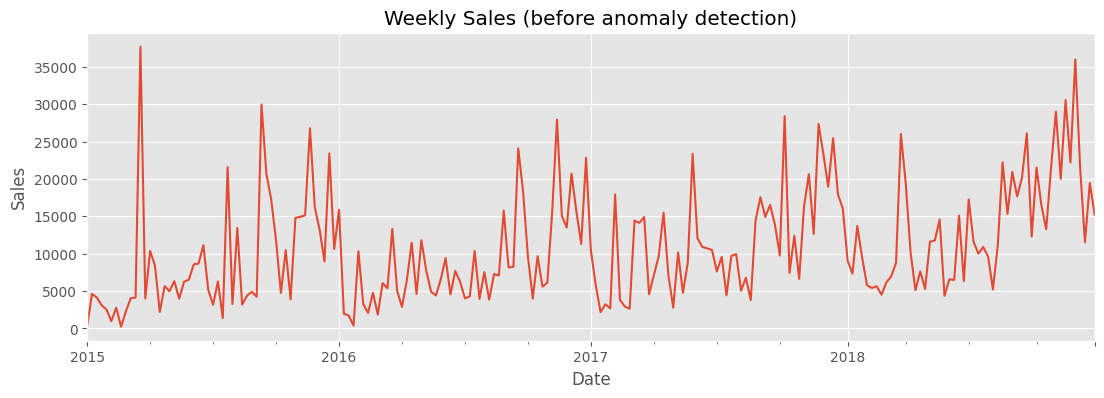

In [53]:
# Set up the weekly series for anomaly detection
weekly_ts = weekly_sales.set_index('Date')['Sales']
plt.figure(figsize=(13, 4))
weekly_ts.plot()
plt.title('Weekly Sales (before anomaly detection)')
plt.ylabel('Sales')
plt.show()

#### Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern

In [54]:
from sklearn.ensemble import IsolationForest
# Isolation Forest expects a 2D table, so we reshape our 1D sales series
X = weekly_ts.values.reshape(-1, 1)
# contamination=0.05 means "assume roughly 5% of weeks are anomalies" -- adjust
# this up/down if it flags too many or too few points for your data
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(X)

# predict() returns -1 for anomalies, 1 for normal points
iso_predictions = iso_model.predict(X)

weekly_df = weekly_ts.reset_index()
weekly_df.columns = ['Date', 'Sales']
weekly_df['iso_anomaly'] = iso_predictions == -1

print('Number of anomalies flagged by Isolation Forest:', weekly_df['iso_anomaly'].sum())
weekly_df[weekly_df['iso_anomaly']]

Number of anomalies flagged by Isolation Forest: 11


,Date,Sales,iso_anomaly
0,2015-01-04,304.508,True
5,2015-02-08,968.534,True
7,2015-02-22,224.912,True
11,2015-03-22,37703.665,True
28,2015-07-19,1387.686,True
36,2015-09-13,29959.137,True
55,2016-01-24,358.522,True
154,2017-12-17,25449.800,True
200,2018-11-04,29017.467,True
202,2018-11-18,30572.447,True


#### Mark the anomalies on a time series plot (use a different color/marker for anomaly points)

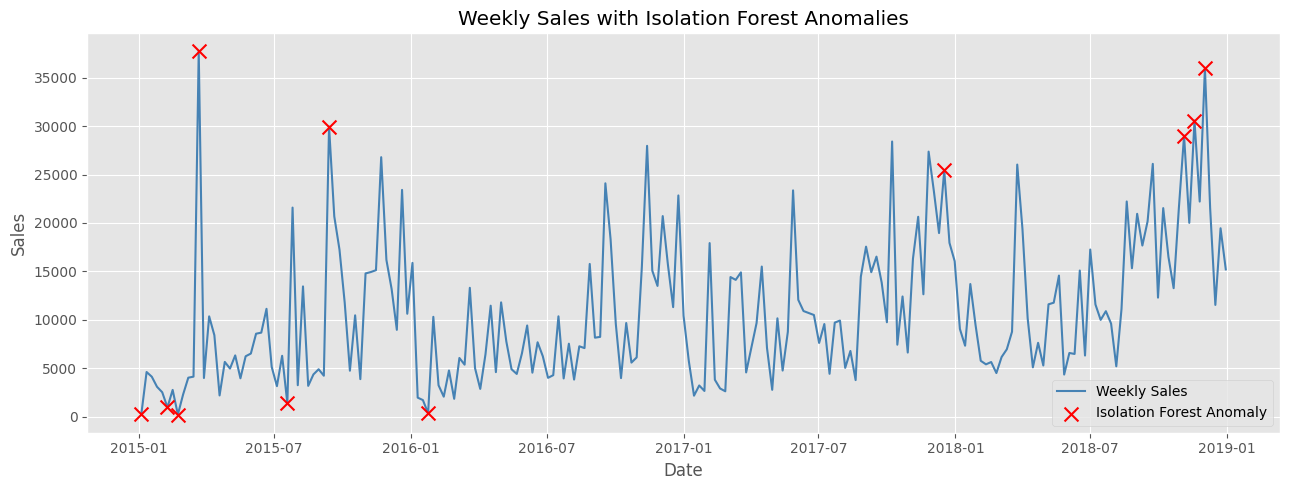

In [55]:
# Plot the weekly sales with Isolation Forest anomalies marked in a different color
plt.figure(figsize=(13, 5))
plt.plot(weekly_df['Date'], weekly_df['Sales'], label='Weekly Sales', color='steelblue')
anomalies = weekly_df[weekly_df['iso_anomaly']]
plt.scatter(anomalies['Date'], anomalies['Sales'], color='red', marker='x', s=100,
            label='Isolation Forest Anomaly', zorder=5)

plt.title('Weekly Sales with Isolation Forest Anomalies')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/isolation_forest_anomalies.png', dpi=150)
plt.show()


In [56]:
# Pull in the merged video game industry context for each flagged anomaly week --
# this is where Step 0's merge actually gets used, to help explain WHY an anomaly happened
anomaly_context = anomalies.merge(
    weekly_sales_merged[['Date', 'Year', 'VG_Industry_Sales']], on='Date', how='left'
)
anomaly_context[['Date', 'Sales', 'Year', 'VG_Industry_Sales']]

,Date,Sales,Year,VG_Industry_Sales
0,2015-01-04,304.508,2015,264.44
1,2015-02-08,968.534,2015,264.44
2,2015-02-22,224.912,2015,264.44
3,2015-03-22,37703.665,2015,264.44
4,2015-07-19,1387.686,2015,264.44
5,2015-09-13,29959.137,2015,264.44
6,2016-01-24,358.522,2016,70.93
7,2017-12-17,25449.800,2017,0.05
8,2018-11-04,29017.467,2018,NaN
9,2018-11-18,30572.447,2018,NaN


#### For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")

Use the `VG_Industry_Sales` column as optional supporting context where relevant
(e.g. "this was also a strong year for video game sales overall, suggesting
broader consumer electronics demand that year, not just a Superstore-specific event"):
- e.g. Week of Nov 2023 (unusually high) → likely Black Friday / holiday sale promotion
- e.g. Week of Jan 2022 (unusually low) → post-holiday slump / stores restocking
- (add a line for every anomaly your model actually flagged)

#### Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean

In [57]:
# Rolling mean and rolling standard deviation of the PRECEDING 4 weeks
# (shift(1) excludes the current week itself -- otherwise a big spike would
# inflate its own rolling average/std and end up hiding itself)
rolling_window = 4
weekly_df['rolling_mean'] = weekly_df['Sales'].shift(1).rolling(window=rolling_window).mean()
weekly_df['rolling_std'] = weekly_df['Sales'].shift(1).rolling(window=rolling_window).std()

# Z-score: (actual - rolling mean) / rolling std
weekly_df['z_score'] = (weekly_df['Sales'] - weekly_df['rolling_mean']) / weekly_df['rolling_std']

# Flag anomaly if the Z-score is beyond +2 or -2
weekly_df['zscore_anomaly'] = weekly_df['z_score'].abs() > 2

print('Number of anomalies flagged by Z-score method:', weekly_df['zscore_anomaly'].sum())
weekly_df[weekly_df['zscore_anomaly']][['Date', 'Sales', 'rolling_mean', 'z_score']]

Number of anomalies flagged by Z-score method: 40


,Date,Sales,rolling_mean,z_score
5,2015-02-08,968.5340,3592.524750,-2.752352
7,2015-02-22,224.9120,2340.011500,-2.242690
9,2015-03-08,4030.7280,1563.535750,2.102431
11,2015-03-22,37703.6650,2671.221250,19.060372
22,2015-06-07,8569.9480,5766.387750,2.327130
24,2015-06-21,11139.4446,7504.611750,2.792849
26,2015-07-05,3158.4000,8384.157900,-2.120808
29,2015-07-26,21590.0800,3995.168000,8.119383
36,2015-09-13,29959.1370,4172.795625,35.956949
46,2015-11-22,26793.6235,12185.782550,2.638264


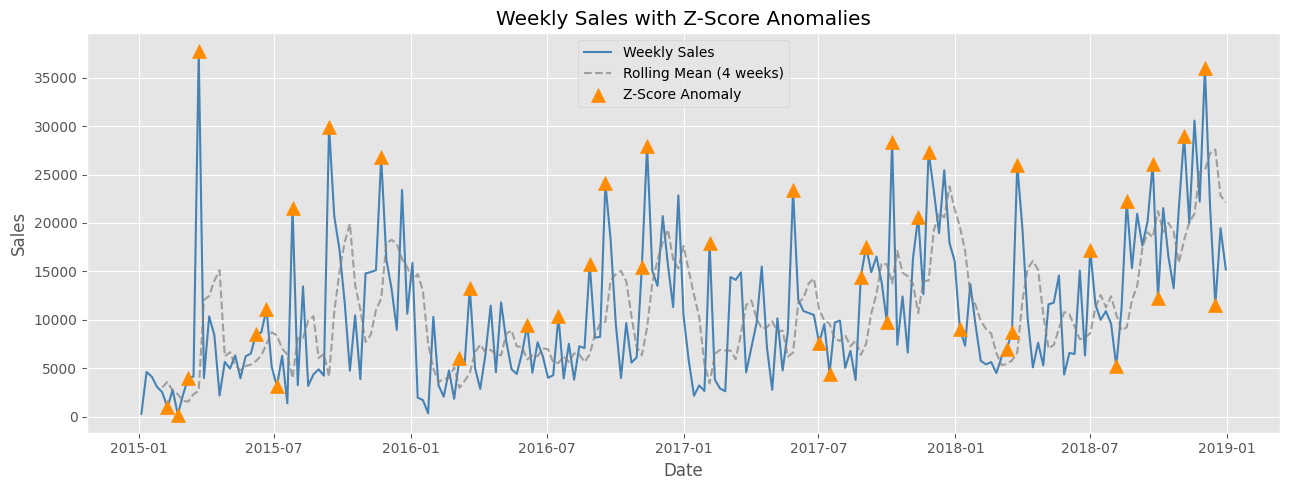

In [58]:
# Plot the weekly sales with Z-score anomalies marked
plt.figure(figsize=(13, 5))
plt.plot(weekly_df['Date'], weekly_df['Sales'], label='Weekly Sales', color='steelblue')
plt.plot(weekly_df['Date'], weekly_df['rolling_mean'], label='Rolling Mean (4 weeks)',
         color='gray', linestyle='--', alpha=0.7)

z_anomalies = weekly_df[weekly_df['zscore_anomaly']]
plt.scatter(z_anomalies['Date'], z_anomalies['Sales'], color='darkorange', marker='^', s=100,
            label='Z-Score Anomaly', zorder=5)

plt.title('Weekly Sales with Z-Score Anomalies')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/zscore_anomalies.png', dpi=150)
plt.show()

#### Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?

In [59]:
# Do both methods flag the same weeks, or different ones?
comparison = weekly_df[['Date', 'Sales', 'iso_anomaly', 'zscore_anomaly']].copy()
comparison['both_flagged'] = comparison['iso_anomaly'] & comparison['zscore_anomaly']
comparison['only_isolation_forest'] = comparison['iso_anomaly'] & ~comparison['zscore_anomaly']
comparison['only_zscore'] = comparison['zscore_anomaly'] & ~comparison['iso_anomaly']

print('Flagged by BOTH methods:', comparison['both_flagged'].sum())
print('Flagged ONLY by Isolation Forest:', comparison['only_isolation_forest'].sum())
print('Flagged ONLY by Z-score:', comparison['only_zscore'].sum())
comparison[comparison['iso_anomaly'] | comparison['zscore_anomaly']]

Flagged by BOTH methods: 6
Flagged ONLY by Isolation Forest: 5
Flagged ONLY by Z-score: 34


,Date,Sales,iso_anomaly,zscore_anomaly,both_flagged,only_isolation_forest,only_zscore
0,2015-01-04,304.5080,True,False,False,True,False
5,2015-02-08,968.5340,True,True,True,False,False
7,2015-02-22,224.9120,True,True,True,False,False
9,2015-03-08,4030.7280,False,True,False,False,True
11,2015-03-22,37703.6650,True,True,True,False,False
22,2015-06-07,8569.9480,False,True,False,False,True
24,2015-06-21,11139.4446,False,True,False,False,True
26,2015-07-05,3158.4000,False,True,False,False,True
28,2015-07-19,1387.6860,True,False,False,True,False
29,2015-07-26,21590.0800,False,True,False,False,True


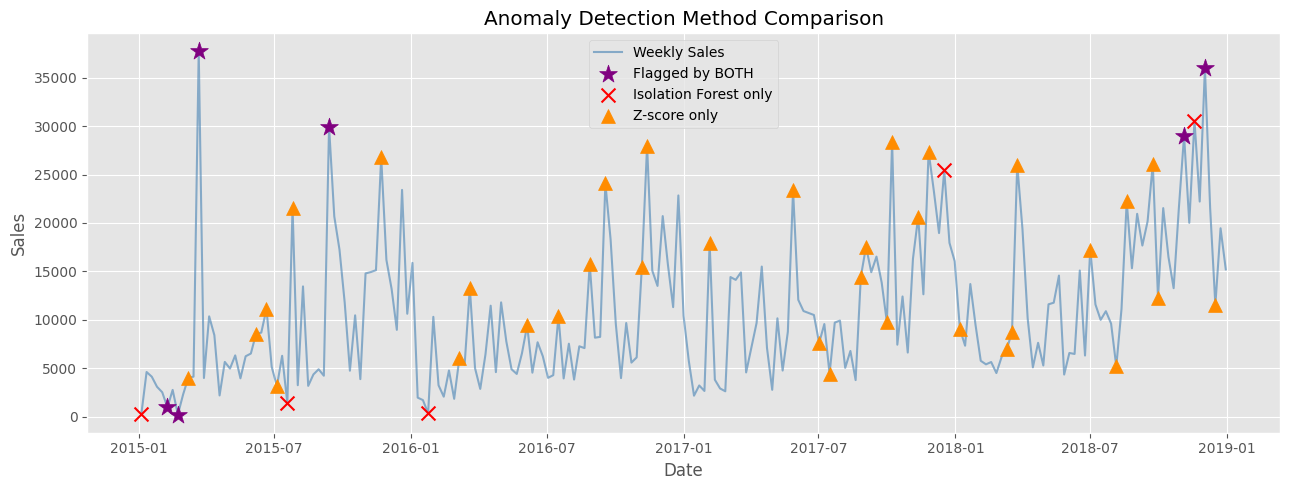

In [60]:
# Visualize both methods together for an easy side-by-side comparison
plt.figure(figsize=(13, 5))
plt.plot(weekly_df['Date'], weekly_df['Sales'], label='Weekly Sales', color='steelblue', alpha=0.6)
both = comparison[comparison['both_flagged']]
only_iso = comparison[comparison['only_isolation_forest']]
only_z = comparison[comparison['only_zscore']]

plt.scatter(both['Date'], both['Sales'], color='purple', marker='*', s=180,
            label='Flagged by BOTH', zorder=6)
plt.scatter(only_iso['Date'], only_iso['Sales'], color='red', marker='x', s=100,
            label='Isolation Forest only', zorder=5)
plt.scatter(only_z['Date'], only_z['Sales'], color='darkorange', marker='^', s=100,
            label='Z-score only', zorder=5)

plt.title('Anomaly Detection Method Comparison')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomaly_method_comparison.png', dpi=150)
plt.show()

### Task 6 — Product Demand Segmentation using Clustering

#### ●	Aggregate data at the product sub-category level with features like:
*	Total sales volume
*	Sales growth rate (year-over-year)
*   Sales volatility (standard deviation of monthly sales)
*	Average order value

In [61]:
subcat_features = []
for subcat in df['Sub-Category'].unique():
    subcat_df = df[df['Sub-Category'] == subcat]

    # 1. Total sales volume
    total_sales = subcat_df['Sales'].sum()

    # 2. YoY growth rate: compare first year's total to last year's total
    yearly = subcat_df.groupby('Year')['Sales'].sum().sort_index()
    if len(yearly) >= 2 and yearly.iloc[0] != 0:
        growth_rate = ((yearly.iloc[-1] - yearly.iloc[0]) / yearly.iloc[0]) * 100
    else:
        growth_rate = 0  # not enough years of data to compute growth

    # 3. Sales volatility: std dev of monthly totals
    monthly = subcat_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
    volatility = monthly.std()

    # 4. Average order value: average Sales per row (each row = one order line)
    avg_order_value = subcat_df['Sales'].mean()

    subcat_features.append({
        'Sub-Category': subcat,
        'Total_Sales': total_sales,
        'Growth_Rate_Pct': growth_rate,
        'Volatility': volatility,
        'Avg_Order_Value': avg_order_value
    })
subcat_df_features = pd.DataFrame(subcat_features).set_index('Sub-Category')
subcat_df_features


,Total_Sales,Growth_Rate_Pct,Volatility,Avg_Order_Value
Sub-Category,,,,
Bookcases,113813.1987,49.846598,2229.359867,503.598224
Chairs,322822.7310,20.954677,4407.232960,531.833165
Labels,12347.7260,36.073373,223.471218,34.587468
Tables,202810.6280,33.078016,3224.082504,645.893720
Storage,219343.3920,38.366108,2822.084310,263.633885
Furnishings,89212.0180,106.824969,1360.017867,95.823865
Art,26705.4100,49.649531,330.488343,34.019631
Phones,327782.4480,35.557607,4052.718221,374.180877
Binders,200028.7850,65.778638,3848.223648,134.067550


#### Apply K-Means Clustering to segment products into demand groups

In [62]:
from sklearn.preprocessing import StandardScaler
feature_cols = ['Total_Sales', 'Growth_Rate_Pct', 'Volatility', 'Avg_Order_Value']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(subcat_df_features[feature_cols])

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=subcat_df_features.index)
X_scaled_df

,Total_Sales,Growth_Rate_Pct,Volatility,Avg_Order_Value
Sub-Category,,,,
Bookcases,-0.194919,-0.247187,-0.097994,0.125325
Chairs,1.924927,-0.505231,1.183878,0.173518
Labels,-1.224017,-0.370201,-1.278638,-0.675202
Tables,0.707723,-0.396953,0.487489,0.368201
Storage,0.875404,-0.349723,0.250877,-0.284256
Furnishings,-0.444433,0.261707,-0.609679,-0.570681
Art,-1.078397,-0.248947,-1.215649,-0.676171
Phones,1.975230,-0.374807,0.975214,-0.095570
Binders,0.679509,-0.104892,0.854851,-0.505405


#### Use the Elbow Method to find the optimal number of clusters

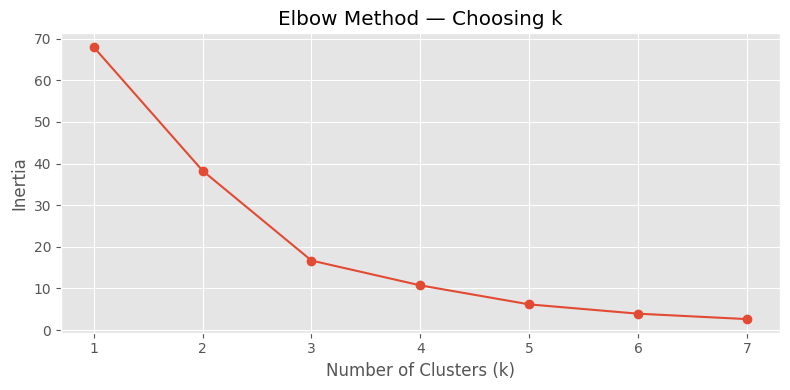

In [63]:
from sklearn.cluster import KMeans
inertias = []
k_range = range(1, min(8, len(subcat_df_features)))  # can't have more clusters than data points
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.title('Elbow Method — Choosing k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150)
plt.show()

In [64]:
# Set this based on what you saw in the elbow plot above
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
subcat_df_features['Cluster'] = kmeans_final.fit_predict(X_scaled)
subcat_df_features.sort_values('Cluster')

,Total_Sales,Growth_Rate_Pct,Volatility,Avg_Order_Value,Cluster
Sub-Category,,,,,
Bookcases,113813.1987,49.846598,2229.359867,503.598224,0
Labels,12347.7260,36.073373,223.471218,34.587468,0
Art,26705.4100,49.649531,330.488343,34.019631,0
Furnishings,89212.0180,106.824969,1360.017867,95.823865,0
Envelopes,16128.0460,-12.121345,234.265716,65.032444,0
Fasteners,3001.9600,30.468364,49.094264,14.027850,0
Paper,76828.3040,91.901971,1024.824982,57.420257,0
Appliances,104618.4030,165.242912,1821.621539,227.926804,0
Supplies,46420.3080,11.276038,1975.222903,252.284283,0


In [65]:
# See what each cluster looks like on average, to help decide a label for it
cluster_summary = subcat_df_features.groupby('Cluster')[feature_cols].mean()
cluster_summary['Num_SubCategories'] = subcat_df_features.groupby('Cluster').size()
cluster_summary

,Total_Sales,Growth_Rate_Pct,Volatility,Avg_Order_Value,Num_SubCategories
Cluster,,,,,
0,54341.708189,58.795823,1027.596300,142.746758,9
1,189238.631000,-29.793120,5442.477300,1645.553313,1
2,239495.780667,56.465168,3489.056075,361.131228,6
3,146248.094000,479.729510,5104.267436,2215.880212,1


#### ●	Label each cluster meaningfully, for example:
*	High Volume, Stable Demand
*	Low Volume, High Volatility
*	Growing Demand
*	Declining Demand

In [66]:
cluster_labels = {
    0: 'High Volume, Stable Demand',
    1: 'Low Volume, High Volatility',
    2: 'Growing Demand',
    3: 'Declining Demand'
}
# NOTE: match these labels up against cluster_summary above -- the cluster NUMBERS
# K-Means assigns are arbitrary, so double check which number actually corresponds
# to which real-world pattern before finalizing labels.
subcat_df_features['Cluster_Label'] = subcat_df_features['Cluster'].map(cluster_labels)
subcat_df_features[['Cluster', 'Cluster_Label'] + feature_cols].sort_values('Cluster')

,Cluster,Cluster_Label,Total_Sales,Growth_Rate_Pct,Volatility,Avg_Order_Value
Sub-Category,,,,,,
Bookcases,0,"High Volume, Stable Demand",113813.1987,49.846598,2229.359867,503.598224
Labels,0,"High Volume, Stable Demand",12347.7260,36.073373,223.471218,34.587468
Art,0,"High Volume, Stable Demand",26705.4100,49.649531,330.488343,34.019631
Furnishings,0,"High Volume, Stable Demand",89212.0180,106.824969,1360.017867,95.823865
Envelopes,0,"High Volume, Stable Demand",16128.0460,-12.121345,234.265716,65.032444
Fasteners,0,"High Volume, Stable Demand",3001.9600,30.468364,49.094264,14.027850
Paper,0,"High Volume, Stable Demand",76828.3040,91.901971,1024.824982,57.420257
Appliances,0,"High Volume, Stable Demand",104618.4030,165.242912,1821.621539,227.926804
Supplies,0,"High Volume, Stable Demand",46420.3080,11.276038,1975.222903,252.284283


#### ●	Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)

In [67]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print('Variance explained by these 2 components:', pca.explained_variance_ratio_.sum().round(3))
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=subcat_df_features.index)
pca_df['Cluster_Label'] = subcat_df_features['Cluster_Label'].values

Variance explained by these 2 components: 0.9


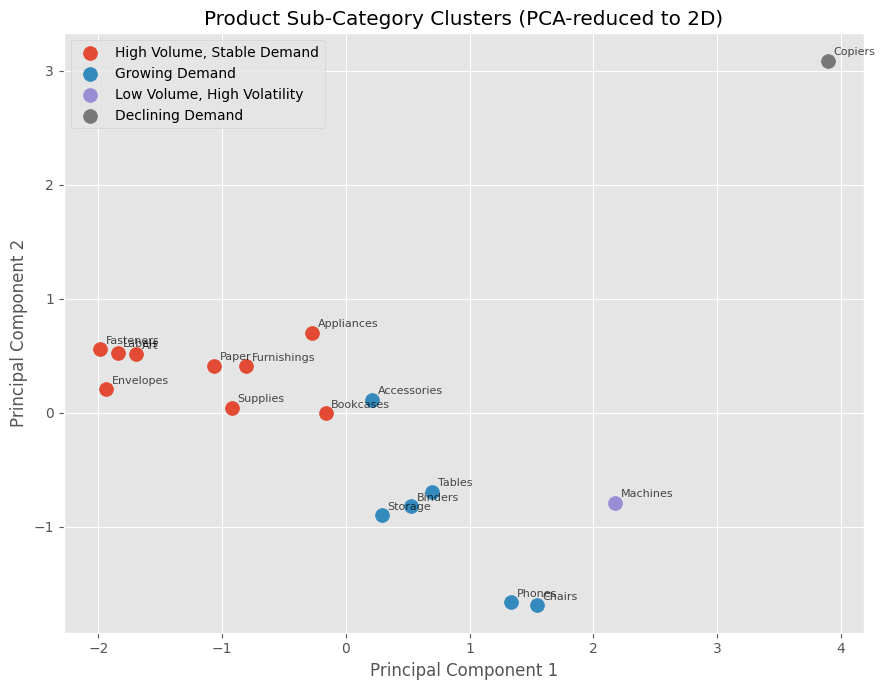

In [68]:
plt.figure(figsize=(9, 7))
for label in pca_df['Cluster_Label'].unique():
    subset = pca_df[pca_df['Cluster_Label'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, s=100)

# Label each point with its sub-category name so the chart is readable
for subcat, row in pca_df.iterrows():
    plt.annotate(subcat, (row['PC1'], row['PC2']), fontsize=8, alpha=0.7,
                 xytext=(4, 4), textcoords='offset points')
plt.title('Product Sub-Category Clusters (PCA-reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.savefig('charts/cluster_pca_scatter.png', dpi=150)
plt.show()

#### ●	Write: what stocking strategy would you recommend for each cluster?

For each cluster label, write a concrete stocking recommendation:
- **High Volume, Stable Demand** → e.g. keep consistent, generous stock levels;
  low risk of overstock since demand is predictable
- **Low Volume, High Volatility** → e.g. stock conservatively, replenish more
  frequently in smaller batches to avoid being stuck with unsold inventory
- **Growing Demand** → e.g. gradually increase stock ahead of the trend; monitor
  closely for continued growth to avoid running out
- **Declining Demand** → e.g. reduce stock levels, consider promotions to clear
  existing inventory, deprioritize warehouse space